In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

data = pd.read_csv("Advertising.csv")
print(data.head())
x = data[["TV","radio","newspaper"]]
y = data["sales"]
print(x,y)
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
model = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=10000, learning_rate = "constant", eta0=0.01)
    )
model.fit(x_train,y_train)
print(model.predict(x_test))

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
        TV  radio  newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns] 0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64
[16.40085033 20.84092503 21.5862061  10.51450085 21.97467256 13.05489814
 20.98025388  7.4143534  13.63920946 15.14210253  8.92142014  6.64967176
 14.51756913  8.76312467  9.72218

In [5]:
y_pred = model.predict(x_test)
y_pred, y_test

(array([16.40085033, 20.84092503, 21.5862061 , 10.51450085, 21.97467256,
        13.05489814, 20.98025388,  7.4143534 , 13.63920946, 15.14210253,
         8.92142014,  6.64967176, 14.51756913,  8.76312467,  9.72218753,
        12.2059021 ,  8.66272666, 16.22506096, 10.23774101, 18.78551939,
        19.61483433, 13.30763565, 12.17783483, 21.35165424,  7.76233953,
         5.80165235, 20.69479325, 11.94196119,  9.16371684,  8.36264356,
        12.50904467,  9.93396033, 21.34768914, 12.21808568, 18.33066024,
        20.05911814, 13.87188314, 20.90856584, 10.96035221,  4.55168952]),
 95     16.9
 15     22.4
 30     21.4
 158     7.3
 128    24.7
 115    12.6
 69     22.3
 170     8.4
 174    11.5
 45     14.9
 66      9.5
 182     8.7
 165    11.9
 78      5.3
 186    10.3
 177    11.7
 56      5.5
 152    16.6
 82     11.3
 68     18.9
 124    19.7
 16     12.5
 148    10.9
 93     22.2
 65      9.3
 60      8.1
 84     21.7
 67     13.4
 125    10.6
 132     5.7
 9      10.6
 18     11.

In [8]:
mean_squared_error(y_test, y_pred)
model.predict([[230,37,69]])[0]

/home/sujita/ds/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(20.486879618497724)

In [7]:
from sklearn.datasets import fetch_california_housing
import seaborn as sns

housing = fetch_california_housing(as_frame = True)
df = housing.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [9]:
X = housing.data 
y = housing.target
X.shape, y.shape

((20640, 8), (20640,))

In [10]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

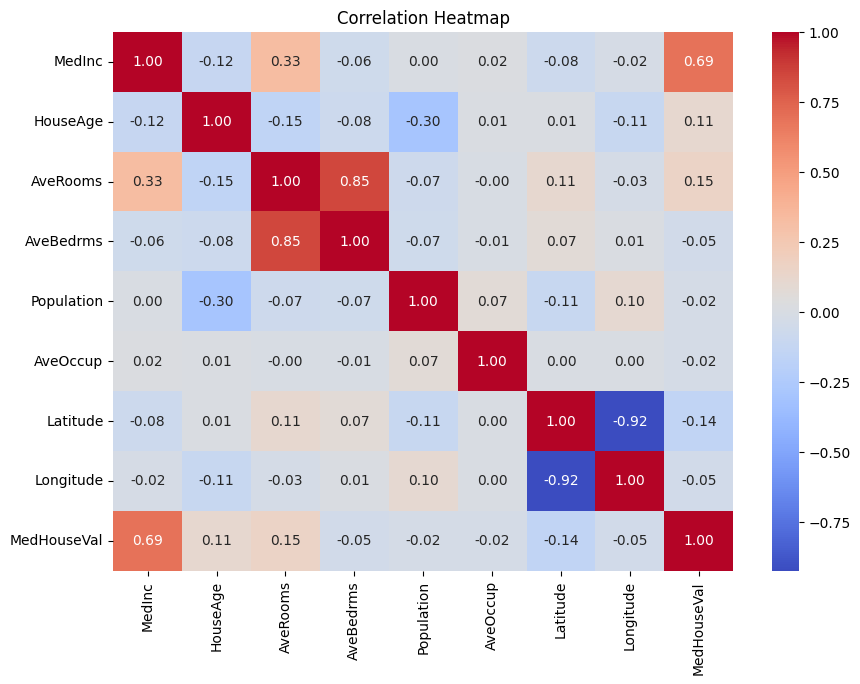

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='MedInc', ylabel='AveBedrms'>

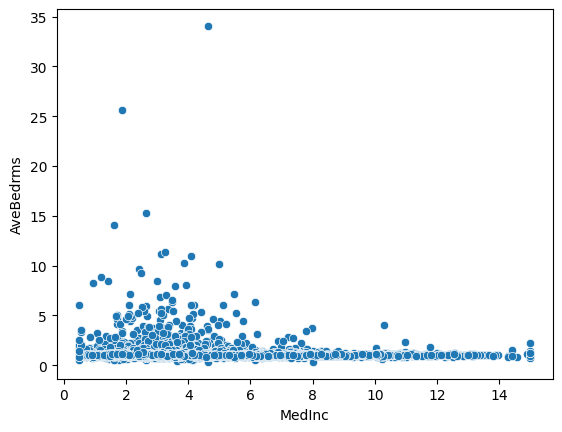

In [12]:
sns.scatterplot(df, x = "MedInc", y = "AveBedrms")

<Axes: xlabel='MedInc', ylabel='Population'>

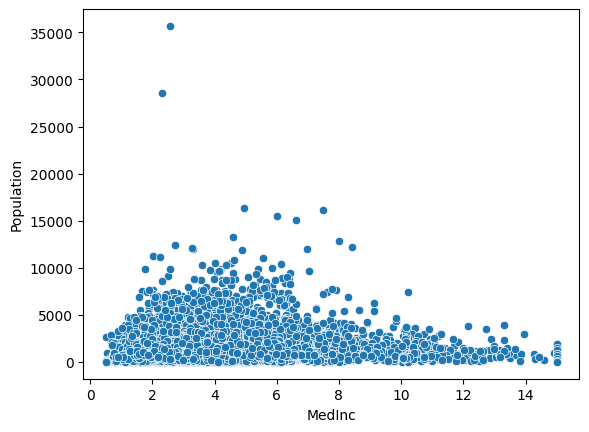

In [13]:
sns.scatterplot(df, x = "MedInc", y = "Population")

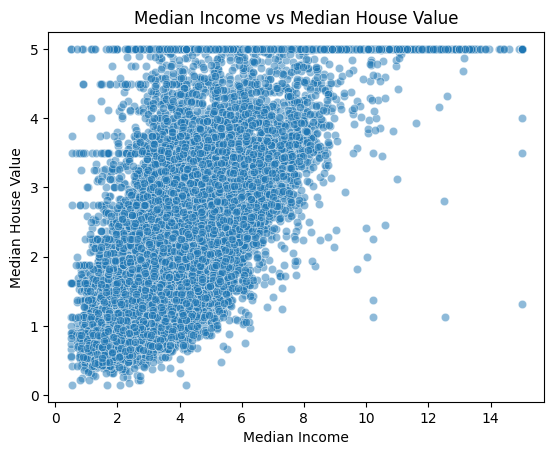

In [14]:
sns.scatterplot(df, x = "MedInc", y = "MedHouseVal", alpha = 0.5)
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel('Median House Value')
plt.show()

In [42]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [15]:
x = df[["MedInc"]]
y = df["MedHouseVal"]
learning_rate = 0.01
print(x,y)


       MedInc
0      8.3252
1      8.3014
2      7.2574
3      5.6431
4      3.8462
...       ...
20635  1.5603
20636  2.5568
20637  1.7000
20638  1.8672
20639  2.3886

[20640 rows x 1 columns] 0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


[1.20991239 1.54409943 1.91708691 ... 4.17738006 1.6438327  1.94539119]


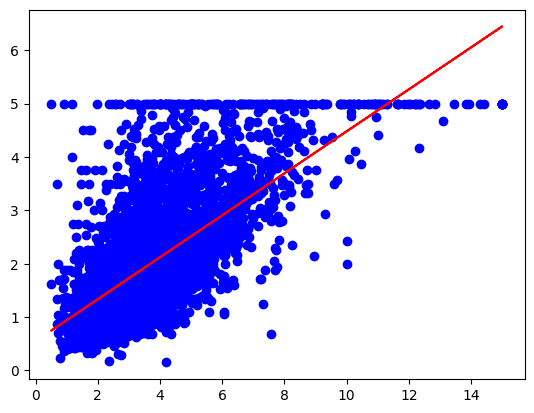

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
model = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=10000, learning_rate = "constant", eta0=learning_rate)
    )
model.fit(x_train,y_train)
print(model.predict(x_test))
plt.scatter(x_test, y_test, color = "blue")
plt.plot(x_test, model.predict(x_test), color = "red", label = "Predicted")

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = model.predict(x_test)
y_pred

array([1.14958917, 1.50606882, 1.90393718, ..., 4.31500772, 1.612455  ,
       1.93412956], shape=(4128,))

In [24]:
import numpy as np
x = np.array(x).reshape(-1,1)
y = np.array(y)
learning_rate = 0.01


In [28]:
model.intercept_, model.coef_

(np.float64(0.4445972916907879), array([0.41933849]))

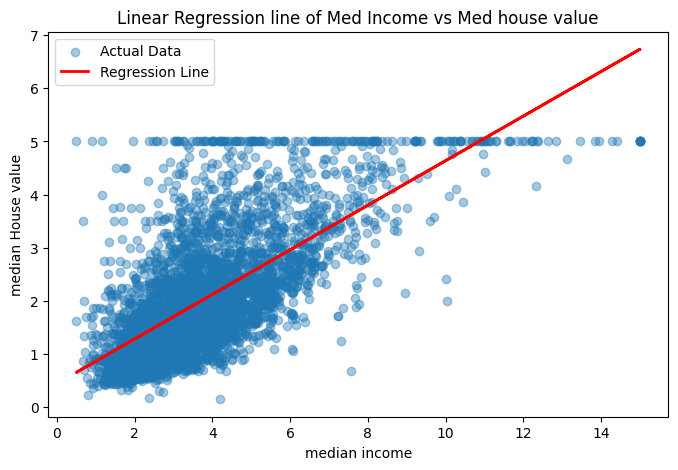

In [34]:
plt.figure(figsize = (8,5))
plt.scatter(x_test, y_test, alpha = 0.4, label = 'Actual Data')
plt.plot(x_test, y_pred, color = 'red', linewidth = 2, label = "Regression Line")
plt.xlabel("median income")
plt.ylabel("median House value")
plt.title("Linear Regression line of Med Income vs Med house value")
plt.legend()
plt.show()

In [36]:
y_test = np.array(y_test)
y_pred = np.array(y_pred)

y_mean = np.mean(y_test)
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - y_mean)**2)
r2_score = (1 - (ss_res / ss_tot))
r2_score

np.float64(0.45885918903846656)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred), np.sqrt(mse)
mae, mse, r2

(0.629908653009376, 0.7091157771765549, 0.45885918903846656)

In [52]:
x = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']]
y = df['MedHouseVal']
learning_rate = 0.01
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
multi_model = LinearRegression()
multi_model.fit(x_train,y_train)

#print(multi_model.predict(x_test))
# plt.scatter(x_test, y_test, color = "blue")
# plt.plot(x_test, model.predict(x_test), color = "red", label = "Predicted")


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
multi_model.intercept_, multi_model.coef_

(np.float64(-37.023277706064015),
 array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
        -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01]))

In [1]:
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)    
r2,mae        #difficult to 

NameError: name 'r2_score' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

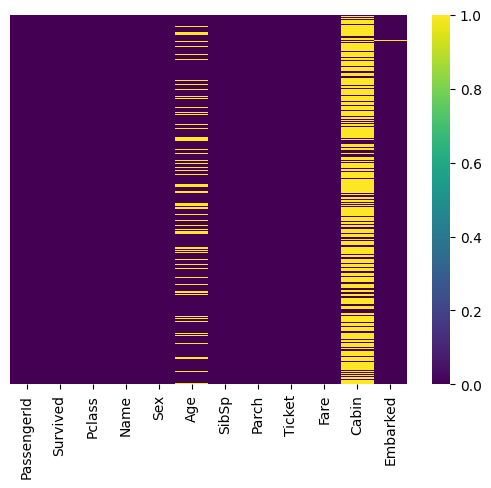

In [22]:
sns.heatmap(train.isnull(), yticklabels = False, cmap ='viridis')
plt.show()

In [24]:
train['Cabin'].isna().sum(),len(train)

(np.int64(687), 891)

In [26]:
687/891*100

77.10437710437711

In [28]:
train['Embarked'].isna().sum(),len(train)

(np.int64(2), 891)

In [30]:
2/891*100

0.22446689113355783

<Axes: xlabel='Survived', ylabel='count'>

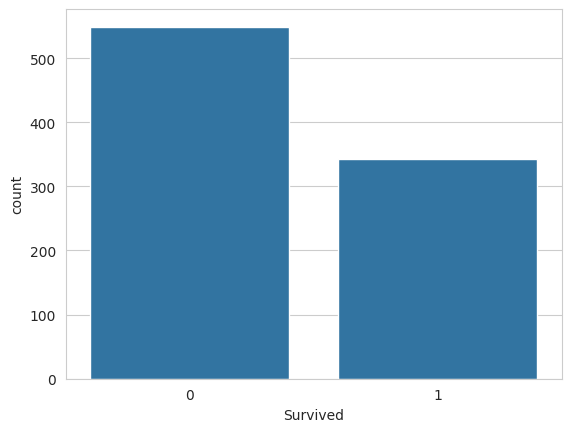

In [35]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data = train)

<Axes: xlabel='Survived', ylabel='count'>

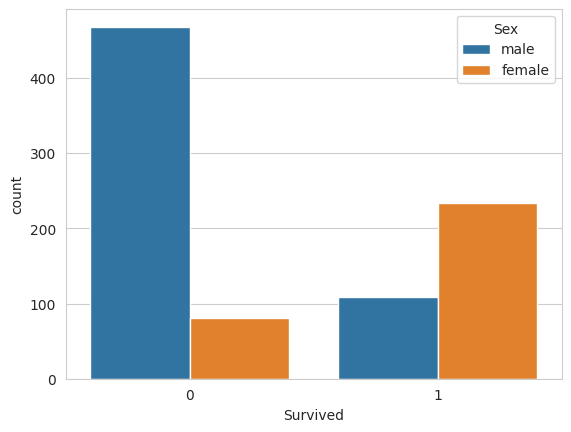

In [37]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue= 'Sex', data = train)

<Axes: xlabel='Survived', ylabel='count'>

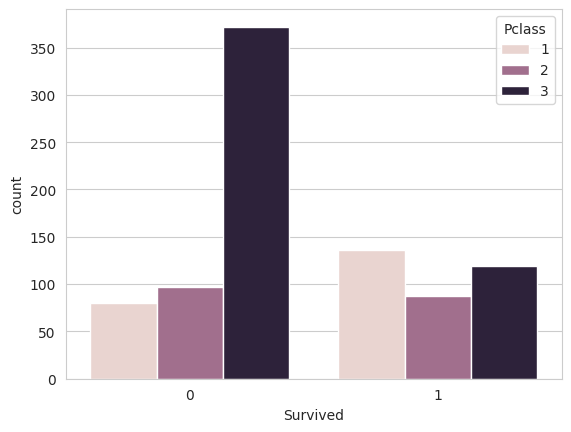

In [42]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue= 'Pclass', data = train)

In [44]:
train['Pclass'].unique()
train['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

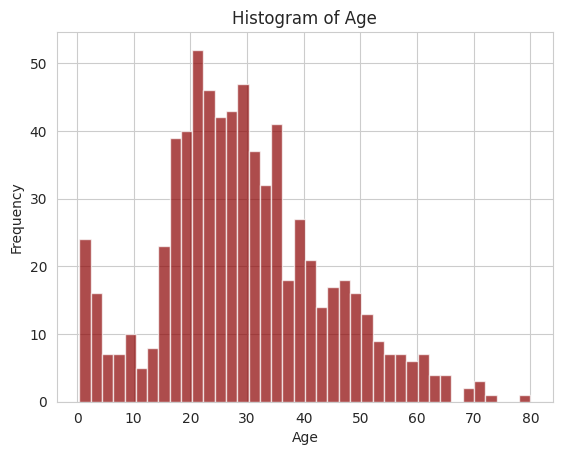

In [51]:
age_hist = train['Age'].hist(bins=40, color = 'darkred', alpha = 0.7)
age_hist.set_title("Histogram of Age")
age_hist.set_xlabel("Age")
age_hist.set_ylabel("Frequency")
plt.show()            #all data are shifted towards mean -> normal distribution 

In [52]:
train['Age'].mean()

np.float64(29.69911764705882)

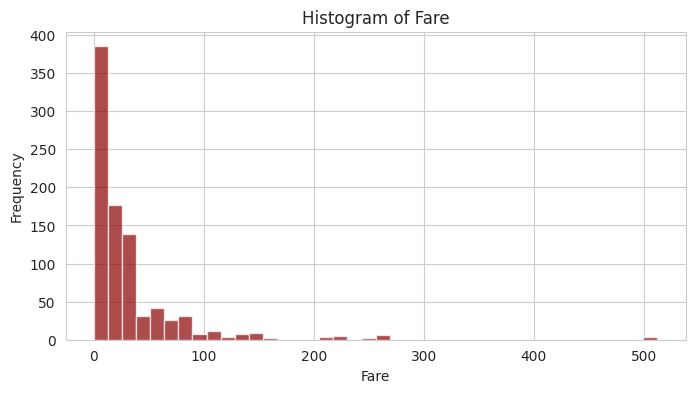

In [54]:
age_hist = train['Fare'].hist(bins=40, color = 'darkred', alpha = 0.7, figsize=(8,4))
age_hist.set_title("Histogram of Fare")
age_hist.set_xlabel("Fare")
age_hist.set_ylabel("Frequency")
plt.show()            #logarithmic distribution